采样率: 256.00 Hz, 5秒样本数: 1280, 总样本数: 401027


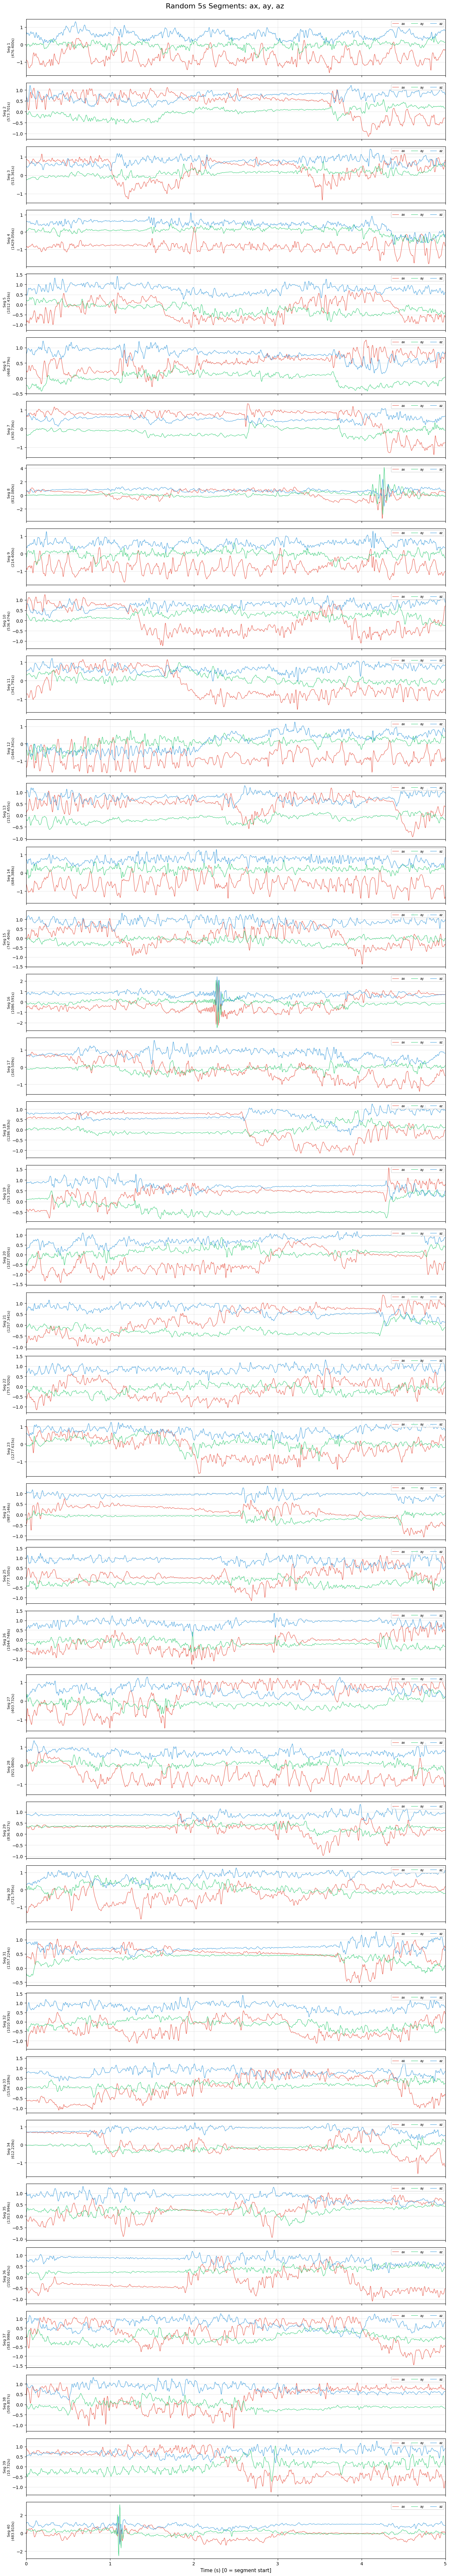

✅ 图像已保存为 segments_plot.png


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========== 读取文件 ==========
file_path = r'\\hulab.lumiani.ai\Data\WSB\Computational_Ethology\processed_Data\Train\6channel\test3_tool1_13.csv'

df = pd.read_csv(file_path)

# 第0列=时间(s)，第1列=ax，第2列=ay，第3列=az
time = df.iloc[:, 0].values
ax = df.iloc[:, 1].values
ay = df.iloc[:, 2].values
az = df.iloc[:, 3].values

# ========== 计算采样率 ==========
dt = np.median(np.diff(time))
fs = 1 / dt
segment_length = int(5 * fs)
total_samples = len(time)

print(f"采样率: {fs:.2f} Hz, 5秒样本数: {segment_length}, 总样本数: {total_samples}")

# ========== 随机截取20段5s数据 ==========
np.random.seed(42)
segments = []
for i in range(40):
    max_start = total_samples - segment_length
    start_idx = np.random.randint(0, max_start)
    end_idx = start_idx + segment_length
    
    t_raw = time[start_idx:end_idx]
    t_rel = t_raw - t_raw[0]  # 相对时间：0点 = 该段起始时刻
    
    segments.append((
        t_rel,                     # 相对时间 0~5s
        t_raw[0],                  # 原始起始时间戳（用于标注）
        ax[start_idx:end_idx],
        ay[start_idx:end_idx],
        az[start_idx:end_idx]
    ))

# ========== 绘图 ==========
fig, axes = plt.subplots(40, 1, figsize=(14, 80), sharex=True)
fig.suptitle('Random 5s Segments: ax, ay, az', fontsize=16, y=0.995)

colors = ['#E74C3C', '#2ECC71', '#3498DB']
labels = ['ax', 'ay', 'az']

for idx, (ax_plot, (t, t_start, sx, sy, sz)) in enumerate(zip(axes, segments)):
    for sig, color, label in zip([sx, sy, sz], colors, labels):
        ax_plot.plot(t, sig, color=color, label=label, linewidth=0.8)
    
    # y轴标注片段编号 + 原始起始时间戳
    ax_plot.set_ylabel(f'Seg {idx+1}\n({t_start:.3f}s)', fontsize=8)
    ax_plot.legend(loc='upper right', fontsize=7, ncol=3)
    ax_plot.grid(True, alpha=0.3)
    ax_plot.set_xlim(0, 5)  # 严格限定每段为5秒

axes[-1].set_xlabel('Time (s) [0 = segment start]', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.savefig('segments_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 图像已保存为 segments_plot.png")